In [31]:
%load_ext autoreload 
%autoreload 2

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt

import model as md
import view as vw

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
# Параметры
F_main_real = 4.91919192e+05
phase_real = 4.59494949e+01
fs_mult = 1.82828283e+01
duration_T = 1.42000000e+02
gen_unstable = 1.32181818e+00
bins=12
SNR = 50 # dB

# Временная сетка
duration = duration_T / F_main_real
fs = F_main_real * fs_mult
t = np.linspace(0, duration, int(duration * fs))

# 1. Общая фаза
phase = md.generate_common_phase(
    t,
    F_main_real,
    gen_unstable,
    phase0_deg=0
)

# 2. Сигналы с заданной фазовой разницей
U, I = md.generate_signals_from_phase(
    phase,
    phase_diff_deg=phase_real
)

# 3. Добавляем шум
U = md.add_SNR(U, SNR)#
I = md.add_SNR(I, SNR)

U=md.adc_quantize(U,int(bins),1)
I=md.adc_quantize(I,int(bins),1)

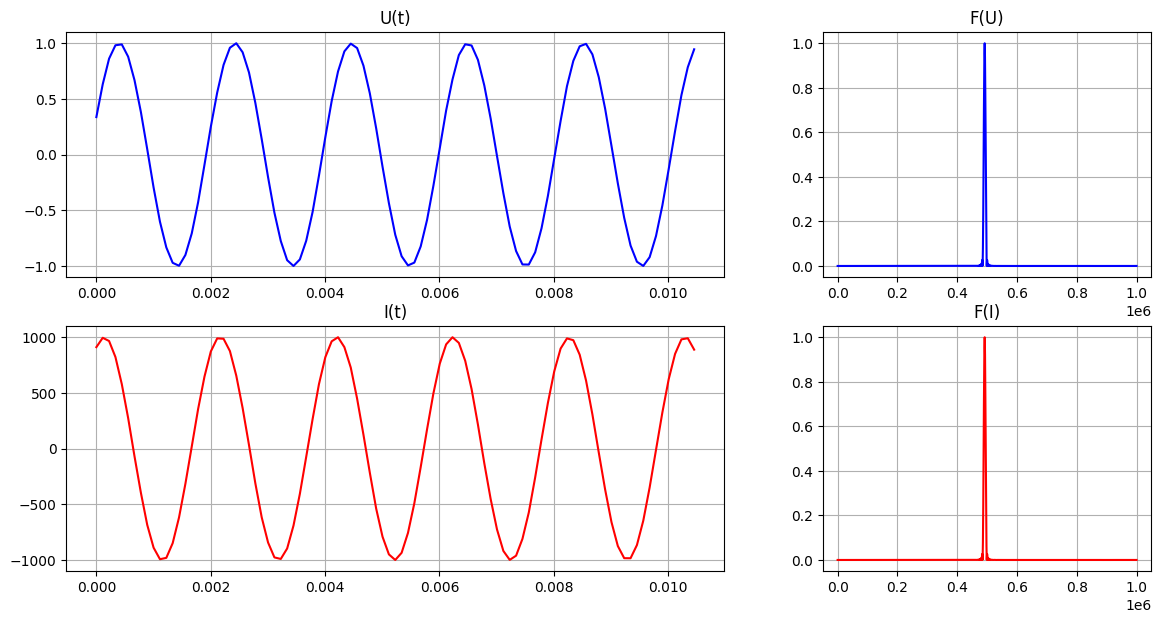

In [33]:
F,V = md.get_spectrum3(t,U)
F_peak_calc = F_main_real#F[np.argmax(V)]
T=1/F_peak_calc
T_counts=md.convert_to_counts(t,T)
window=T_counts*5

vw.show_I_U_2(t,I,U,0,window)

In [34]:
#t_f, U_f=md.filter_butter_bandpass(t,U,F_peak_calc,100e3,5)
#t_f, I_f=md.filter_butter_bandpass(t,I,F_peak_calc,100e3,5)
#
#vw.show_I_U_2(t_f,I_f, U_f,0,window)

In [35]:
phase_methods = [
    md.get_phase_Maxpoint,
    md.get_phase_Zero_crossings,
    md.get_phase_FFT,
    md.get_phase_Hilbert,
    md.get_phase_Xcor,
    md.get_phase_Lockin,
    md.get_phase_swf3p,
    md.get_phase_swff4p,
    md.get_phase_SWFR
]

for i in range(0,len(phase_methods),1):
    phase=phase_methods[i](t, I,U, F_peak_calc)
    div=abs(phase_real-phase)
    print(phase_methods[i].__name__)
    print (" phase extimated=",phase," phase div=",div)


get_phase_Maxpoint
 phase extimated= 46.523601132665135  phase div= 0.5741062326651374
get_phase_Zero_crossings
 phase extimated= 45.96475840029966  phase div= 0.015263500299660393
get_phase_FFT
 phase extimated= 45.95015844240962  phase div= 0.0006635424096188558
get_phase_Hilbert
 phase extimated= 45.96660306672515  phase div= 0.017108166725151364
get_phase_Xcor
 phase extimated= 45.9499321205062  phase div= 0.0004372205061997647
get_phase_Lockin
 phase extimated= 44.994623796295976  phase div= 0.9548711037040221
get_phase_swf3p
 phase extimated= 45.94918248058934  phase div= 0.00031241941065474066
get_phase_swff4p
 phase extimated= 45.94920032578784  phase div= 0.00029457421215539625
get_phase_SWFR
 phase extimated= 45.94918248058934  phase div= 0.00031241941065474066
